# Get to Know a Dataset: NUVIEW Open Data

This notebook serves as a guided tour of the [NUVIEW Open Data](https://registry.opendata.aws/nuview-opendata) dataset. More usage examples, tutorials, and documentation for this dataset and others can be found at the [Registry of Open Data on AWS](https://registry.opendata.aws/).

At the top level of our S3 bucket, we have multiple key prefixes, each key prefix defines US state that the data was collected in as well as the type of product.
For example `ak_alaska_bare_earth` key prefix contains LIDAR derived product of bare earth surface collected across the state of Alaska.

Underneath the top level key prefix the data is organized into acqusition projects. Each project represents single acqusition contract between data proider and state officials.

For example under `ak_alaska_bare_earth` key prefix there are several projects:

- 2024_AK_Valdez_Glacier/
- AGO_EVOS_Copper_River_2023/
- 20241219_Skagway_Alaska_Rd3_FINAL/

Under each project the files are organized according to the USGS [Lidar Base Specification](https://www.usgs.gov/ngp-standards-and-specifications/lidar-base-specification-online) for collections under the 3D Elevation Program.
 
Full documentation for this dataset can be found at: https://github.com/s22s/nuview-opendata




## How to access NUVIEW Open Data 

First we will import the Python libraries required throughout this notebook.


In [2]:
# This notebook requires the following additional libraries
# (please install using the preferred method for your environment, e.g. pip, conda):
#
# boto3 >= 1.38.23
# polars >= 1.30.0
# matplotlib >= 3.10.3 
# numpy >= 1.21.0
# pdal
# rasterio
# pyvista[jupyter]

# Import the libraries required for this notebook

# Built-ins
import json
import tempfile
from pprint import pprint

# Installed libraries
import pdal
import numpy as np
import pyvista as pv
import mercury as mr

import matplotlib.pyplot as plt
from matplotlib import cm

import rasterio
from rasterio.io import MemoryFile
from rasterio.plot import show

import boto3
from botocore import UNSIGNED
from botocore.config import Config

Next, we will define the location of our dataset, create our boto3 S3 client, and list the top level prefixes in our S3 bucket. Here we see there is only one top-level prefix in our bucket.

In [3]:
# Location of the S3 bucket for this dataset
bucket = "nuview-alaska-prod" # (TODO: replace)

# List the top level of the bucket using boto3. Because this is a public bucket, we don't need to sign requests.
# Here we set the signature version to unsigned, which is required for public buckets.
# s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))
s3 = boto3.client('s3')

# Print the items in the top-level prefixes
for item in s3.list_objects_v2(Bucket=bucket, Delimiter='/')['CommonPrefixes']:
    print(item['Prefix'])

ak_alaska_bare_earth/
ak_alaska_generic_gray/
ak_alaska_intensity/
ak_alaska_maximum_surface_height/
ak_alaska_pointcloud/
ak_alaska_swath_separation/


Looking into the top-level S3 prefix of our dataset, we see that the data have been separated into datasets based on location (state) and product type.

In [3]:
# List the key prefixes within the top level 'ak_alaska_bare_earth/' prefix
for item in s3.list_objects_v2(Bucket=bucket, Prefix='ak_alaska_bare_earth/', Delimiter='/', MaxKeys=10)['CommonPrefixes']:
    print(item['Prefix'])

ak_alaska_bare_earth/20241219_Skagway_Alaska_Rd3_FINAL/
ak_alaska_bare_earth/2024_AK_Valdez_Glacier/
ak_alaska_bare_earth/AGO_EVOS_Copper_River_2023/
ak_alaska_bare_earth/AK_Copper_River_FINAL/
ak_alaska_bare_earth/AK_DNR_Kotzebue_FINAL/
ak_alaska_bare_earth/Talkeetna_Lidar_FINAL/
ak_alaska_bare_earth/USGS_-_SE_Landslides_FINAL/
ak_alaska_bare_earth/fairbanks_unalakleet_nv5_09_sep_2024/


Listing key prefixes under `ak_alaska_bare_earth` reveales several project names.
Let's look at `AK_Copper_River_FINAL`. 

In [4]:
# List the keys within the 'ak_alaska_bare_earth/AK_Copper_River_FINAL/' prefix.
for item in s3.list_objects_v2(Bucket=bucket, Prefix='ak_alaska_bare_earth/AK_Copper_River_FINAL/', MaxKeys=10)['Contents']:
    print(item['Key'])

ak_alaska_bare_earth/AK_Copper_River_FINAL/bare_earth/be_rasters/utm_zone_06/UTM6_0291_0801_2_2024.cog.tiff
ak_alaska_bare_earth/AK_Copper_River_FINAL/bare_earth/be_rasters/utm_zone_06/UTM6_0291_0802_2_2024.cog.tiff
ak_alaska_bare_earth/AK_Copper_River_FINAL/bare_earth/be_rasters/utm_zone_06/UTM6_0291_0802_4_2024.cog.tiff
ak_alaska_bare_earth/AK_Copper_River_FINAL/bare_earth/be_rasters/utm_zone_06/UTM6_0291_0803_4_2024.cog.tiff
ak_alaska_bare_earth/AK_Copper_River_FINAL/bare_earth/be_rasters/utm_zone_06/UTM6_0291_0804_2_2024.cog.tiff
ak_alaska_bare_earth/AK_Copper_River_FINAL/bare_earth/be_rasters/utm_zone_06/UTM6_0291_0804_4_2024.cog.tiff
ak_alaska_bare_earth/AK_Copper_River_FINAL/bare_earth/be_rasters/utm_zone_06/UTM6_0291_0805_2_2024.cog.tiff
ak_alaska_bare_earth/AK_Copper_River_FINAL/bare_earth/be_rasters/utm_zone_06/UTM6_0291_0805_4_2024.cog.tiff
ak_alaska_bare_earth/AK_Copper_River_FINAL/bare_earth/be_rasters/utm_zone_06/UTM6_0292_0801_1_2024.cog.tiff
ak_alaska_bare_earth/AK_Copp

The `bare_earth/be_rasters` key prefix follows the USGS [Lidar Base Specification](https://www.usgs.gov/ngp-standards-and-specifications/lidar-base-specification-online) for collections under the 3D Elevation Program. 
Next the files are organized based on the UTM zone they were collected in. Finally the file name consist of the UTM6 grid cell coordinates and the acquisition date.
All raster files are Cloud Optimized GeoTiffs.

Let's take a look at one of the files.

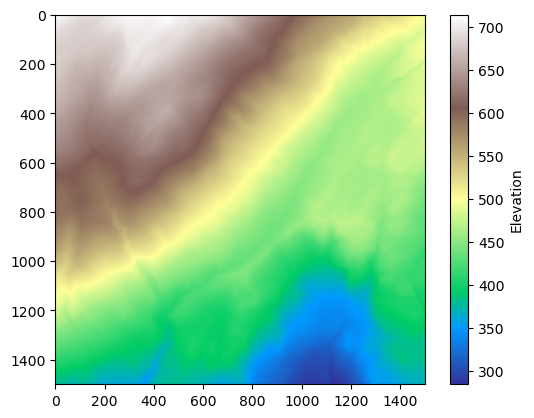

In [5]:
# First we'll load the data into memory and create an elevation image.

file_key = "ak_alaska_bare_earth/AGO_EVOS_Copper_River_2023/bare_earth/be_rasters/utm_zone_06/UTM6_0315_0807_4_2024.cog.tiff"

with s3.get_object(Bucket=bucket, Key=file_key)['Body'] as data:
    with MemoryFile(data.read()) as memfile:
     with memfile.open() as src:
        dem = src.read(1)

        # Show as an image with 'terrain' color map
        plt.imshow(dem, cmap="terrain")
        plt.colorbar(label="Elevation")
        plt.show()


Now let's add hill shade.

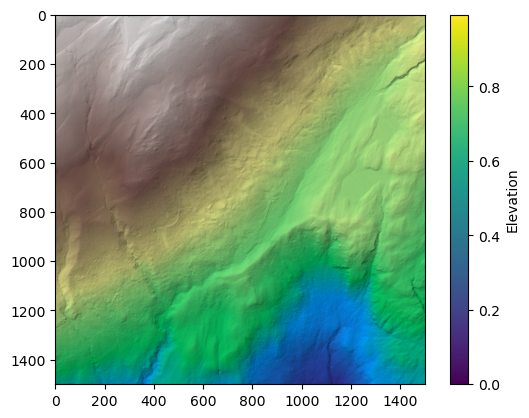

In [6]:
# Simple hill shading algorithm
def hillshade(array, azimuth=315, altitude=45):
    x, y = np.gradient(array)
    slope = np.pi/2 - np.arctan(np.sqrt(x*x + y*y))
    aspect = np.arctan2(-x, y)
    az = np.radians(azimuth)
    alt = np.radians(altitude)
    shaded = np.sin(alt)*np.sin(slope) + np.cos(alt)*np.cos(slope)*np.cos(az-aspect)
    return (shaded + 1) / 2

with s3.get_object(Bucket=bucket, Key=file_key)['Body'] as data:
    with MemoryFile(data.read()) as memfile:
     with memfile.open() as src:
        dem = src.read(1)
        dem_norm = (dem - np.nanmin(dem)) / (np.nanmax(dem) - np.nanmin(dem))
        hs = hillshade(dem)
        
        # Multiply colormap RGB by hillshade for terrain effect
        rgb = cm.terrain(dem_norm)[:, :, :3]
        rgb_hs = rgb * hs[..., np.newaxis]

        # Show as an image with hill shade and 'terrain' color map
        plt.imshow(rgb_hs)
        plt.colorbar(label="Elevation")
        plt.show()

## Accessing NUVIEW Open Data LIDAR point cloud data

Let's look at the original lidar point cloud file that this DEM was derived from.
As before the key prefix structure follows the USGS [Lidar Base Specification](https://www.usgs.gov/ngp-standards-and-specifications/lidar-base-specification-online) for collections under the 3D Elevation Program so we need to look for point cloud files under `ak_alaska_pointcloud/AGO_EVOS_Copper_River_2023/point_cloud`.
Let's list the contents of that prefix:

In [7]:
# List items under 'ak_alaska_pointcloud/AGO_EVOS_Copper_River_2023/point_cloud' prefix:
for item in s3.list_objects_v2(Bucket=bucket, Prefix='ak_alaska_pointcloud/AGO_EVOS_Copper_River_2023/point_cloud', MaxKeys=10)['Contents']:
    print(item['Key'])

ak_alaska_pointcloud/AGO_EVOS_Copper_River_2023/point_cloud/tilecls/Orthometric/utm_zone_06/UTM6_0291_0801_2_2024.copc.laz
ak_alaska_pointcloud/AGO_EVOS_Copper_River_2023/point_cloud/tilecls/Orthometric/utm_zone_06/UTM6_0291_0802_2_2024.copc.laz
ak_alaska_pointcloud/AGO_EVOS_Copper_River_2023/point_cloud/tilecls/Orthometric/utm_zone_06/UTM6_0291_0802_4_2024.copc.laz
ak_alaska_pointcloud/AGO_EVOS_Copper_River_2023/point_cloud/tilecls/Orthometric/utm_zone_06/UTM6_0291_0803_4_2024.copc.laz
ak_alaska_pointcloud/AGO_EVOS_Copper_River_2023/point_cloud/tilecls/Orthometric/utm_zone_06/UTM6_0291_0804_2_2024.copc.laz
ak_alaska_pointcloud/AGO_EVOS_Copper_River_2023/point_cloud/tilecls/Orthometric/utm_zone_06/UTM6_0291_0804_4_2024.copc.laz
ak_alaska_pointcloud/AGO_EVOS_Copper_River_2023/point_cloud/tilecls/Orthometric/utm_zone_06/UTM6_0291_0805_2_2024.copc.laz
ak_alaska_pointcloud/AGO_EVOS_Copper_River_2023/point_cloud/tilecls/Orthometric/utm_zone_06/UTM6_0291_0805_4_2024.copc.laz
ak_alaska_pointc

All point cloud files in the dataset are LAZ version 1.4 with [COPC](https://copc.io) layout.

Let's take a look at one of the LAZ files:

In [5]:
# Let's get the file first and keep as temporary file for further processing.
file_key='ak_alaska_pointcloud/AGO_EVOS_Copper_River_2023/point_cloud/tilecls/Orthometric/utm_zone_06/UTM6_0315_0807_4_2024.copc.laz'

with s3.get_object(Bucket=bucket, Key=file_key)['Body'] as data:
    with tempfile.NamedTemporaryFile() as laz_file:
        laz_file.write(data.read())

        pipeline_json = {
            "pipeline": [
                {
                    "type": "readers.las",
                    "filename": laz_file.name
                }
            ]
        }
        
        pipeline = pdal.Pipeline(json.dumps(pipeline_json))
        pipeline.execute()
        
        # Get metadata (same as pdal info)
        metadata = pipeline.metadata
        mr.JSON(metadata, level=2)

Let's render the point cloud in 3d.

In [6]:
pts = pipeline.arrays[0]

meta = metadata["metadata"]["readers.las"]
scale = np.array([meta["scale_x"], meta["scale_y"], meta["scale_z"]])
offset = np.array([meta["offset_x"], meta["offset_y"], meta["offset_z"]])

X = pts["X"] * scale[0] + offset[0]
Y = pts["Y"] * scale[1] + offset[1]
Z = pts["Z"] * scale[2] + offset[2]

cloud = np.vstack([X, Y, Z]).T

p = pv.PolyData(cloud)
plotter = pv.Plotter(notebook=True)
plotter.add_points(p, scalars=Z, render_points_as_spheres=False, point_size=3, cmap="terrain")
plotter.show()

Widget(value='<iframe src="http://localhost:65349/index.html?ui=P_0x32457ba60_0&reconnect=auto" class="pyvista…

<!-- DATA PROVIDER INSTRUCTIONS
This section is less prescriptive / freeform than previous sections. The goal here is to show an opinionated example of answering a question using your data. The scale of your dataset may preclude a full example, and so feel free to limit the scope of this example (e.g. work on a subset of data). Users should be able to replicate your example in this notebook, and get a sense of how they would scale up.

A "toy" example is better than no example.

Ideally, your example would:
1. Transmit some of your domain & dataset experience to the reader, drawing on your own work as much as possible
2. Provide a jumping off point for users to extend your work, and do novel work of their own.

DATA PROVIDER INSTRUCTIONS -->

### Q: What is one question that you have answered using these data? Can you show us how you came to that answer?

EXAMPLE - REPLACE

Lorem ipsum dolor sit amet, consectetur adipiscing elit. Praesent sem enim, finibus vel leo vel, blandit interdum tortor. In lectus dolor, congue eu odio vel, euismod facilisis lacus. Vestibulum aliquet, quam in rhoncus tempus, arcu massa suscipit lacus, nec fermentum quam justo nec lacus. Duis id leo fermentum ante tempor pulvinar eu vitae ligula. Cras feugiat vel ligula sit amet lacinia. Mauris sit amet sem vestibulum ligula volutpat iaculis in eu velit. Sed turpis magna, porta ac nisi vitae, maximus volutpat mi. Vestibulum mattis est eros, nec pellentesque nisi iaculis sed. 

EXAMPLE - REPLACE

<!-- DATA PROVIDER INSTRUCTIONS
This section is, like the previous one, intended to be freeform / non-prescriptive. The goal here is to provide a challenge to the community to do something novel with your dataset. That can either be novel in terms of the task, or novel in terms of methodological or computational approach.

Another way to consider this section, is as a wishlist. If you were less constrained by time, cost, skill, etc., what would you like to see achieved using these data? 

The challenge should, however, be somewhat realistic. A challenge that assumes e.g. original data collection, is likely to go unanswered.
DATA PROVIDER INSTRUCTIONS -->

### Q: What is one unanswered question that you think could be answered using these data? Do you have any recommendations or advice for someone wanting to answer this question?

EXAMPLE - REPLACE

Lorem ipsum dolor sit amet, consectetur adipiscing elit. Praesent sem enim, finibus vel leo vel, blandit interdum tortor. In lectus dolor, congue eu odio vel, euismod facilisis lacus. Vestibulum aliquet, quam in rhoncus tempus, arcu massa suscipit lacus, nec fermentum quam justo nec lacus. Duis id leo fermentum ante tempor pulvinar eu vitae ligula. Cras feugiat vel ligula sit amet lacinia. Mauris sit amet sem vestibulum ligula volutpat iaculis in eu velit. Sed turpis magna, porta ac nisi vitae, maximus volutpat mi. Vestibulum mattis est eros, nec pellentesque nisi iaculis sed. 

EXAMPLE - REPLACE